# Recovering a TIB 

In [5]:
import numpy as np
import scipy.linalg as la
import matplotlib.pyplot as plt

from ga.filters.tib import (null_basis_realization, build_tib_from_directions,
                            mimo_poles_to_ir, krylov_basis, poles_chebyshev_roots)
from ga.reducers.hankel import msvdreduce, msvdreduce_fixed, blkhankel, lschur, msvdreduce_fast

## A Known MIMO TIB system 

In [6]:
rng = np.random.default_rng(3)
n, q, p, L = 10, 5, 3, 200                         # order, inputs, outputs, IR lags
poles0 = poles_chebyshev_roots(n, 0.0, 0.85)            # real, distinct poles
V0 = rng.standard_normal((q, n)); V0 /= np.linalg.norm(V0, axis=0)   # null vectors
C0 = rng.standard_normal((p, n))

sys0 = null_basis_realization(poles0, V0)
A0 = np.real(sys0.A(dense=True)); B0 = np.real(sys0.B(dense=True))
ir0 = np.real(mimo_poles_to_ir(poles0, V0, C0, L))      # (p, q, L) -- the "data"

print(f"order n={n}, inputs q={q}, outputs p={p}, IR lags L={L}")
print(f"TIB balance |A A^T + B B^T - I| = {np.max(np.abs(A0@A0.T + B0@B0.T - np.eye(n))):.1e}")

order n=10, inputs q=5, outputs p=3, IR lags L=200
TIB balance |A A^T + B B^T - I| = 2.2e-16


In [7]:
ir0.shape 

(3, 5, 200)

## Visualizing the impulse response  `h[out, in](lag)`

The IR is a transfer-function matrix: 3 outputs × 5 inputs = 15 SISO curves over 200 lags.
- **Grid**: rows = outputs, cols = inputs (first ~60 lags, since it decays fast). Set `sharey=False` if small channels get squashed.
- **Energy decay** `‖h(τ)‖_F`: overall memory / time-scales — confirms the IR has died out within `L` before feeding it to the reducer.

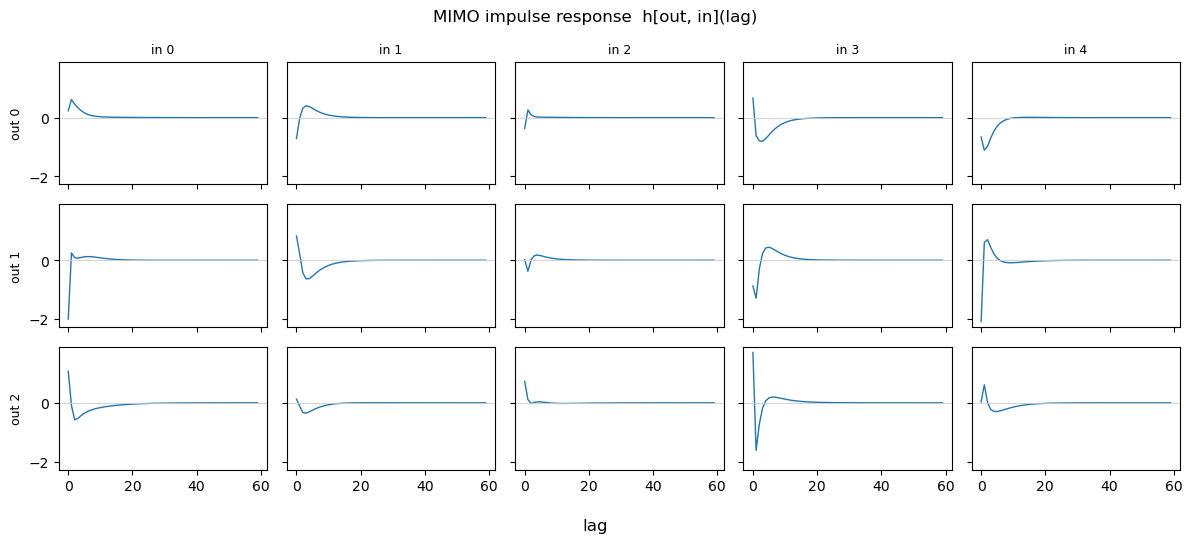

In [8]:
p, q, L = ir0.shape
show = min(60, L)                         # IR decays fast; show the first ~60 lags
fig, axes = plt.subplots(p, q, figsize=(2.4 * q, 1.8 * p), sharex=True, sharey=True)
for i in range(p):
    for j in range(q):
        ax = axes[i, j]
        ax.plot(np.arange(show), ir0[i, j, :show], lw=1)
        ax.axhline(0, color="0.8", lw=0.6)
        if i == 0:
            ax.set_title(f"in {j}", fontsize=9)
        if j == 0:
            ax.set_ylabel(f"out {i}", fontsize=9)
fig.supxlabel("lag")
fig.suptitle("MIMO impulse response  h[out, in](lag)")
fig.tight_layout()
plt.show()

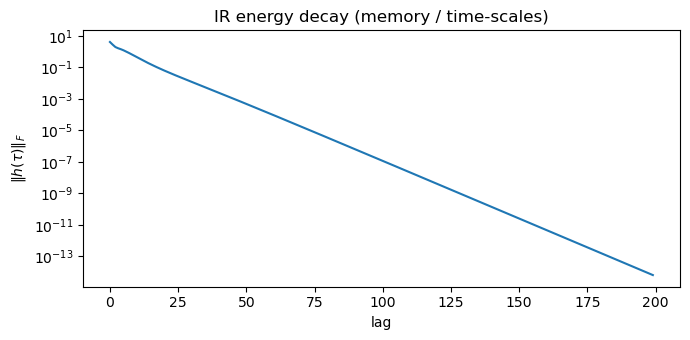

In [9]:
energy = np.linalg.norm(ir0, axis=(0, 1))      # ||h(tau)||_F per lag
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.semilogy(energy)
ax.set_xlabel("lag")
ax.set_ylabel(r"$\|h(\tau)\|_F$")
ax.set_title("IR energy decay (memory / time-scales)")
fig.tight_layout()
plt.show()

In [17]:
w_ship, u_ship = msvdreduce_fixed(ir0, n)

In [18]:
np.sort(w_ship) 

array([0.00523246+0.j, 0.04632223+0.j, 0.12447962+0.j, 0.23205404+0.j,
       0.35851535+0.j, 0.49148465+0.j, 0.61794596+0.j, 0.72552038+0.j,
       0.80367777+0.j, 0.84476754+0.j])

In [19]:
poles0

array([0.00523246, 0.04632223, 0.12447962, 0.23205404, 0.35851535,
       0.49148465, 0.61794596, 0.72552038, 0.80367777, 0.84476754])